Unconfined Ditch Results
------------------------------------------------------------
Q (cms)      = 2.295e-05
K (m/s)      = 1.7e-05
K (ft/s)     = 5.57742782152e-05
K (ft/day)   = 4.8188976378
dx           = 0.1

  i            x            w            h          h^2        h_obs
  0     0.000000     0.000000     0.430000     0.184900     0.430000
  1     0.100000     0.000000     0.426849     0.182200     0.426000
  2     0.200000     0.000000     0.423674     0.179500     0.413000
  3     0.300000     0.000000     0.420476     0.176800     0.407000
  4     0.400000     0.000000     0.417253     0.174100     0.402000
  5     0.500000     0.000000     0.414005     0.171400     0.399000
  6     0.600000     0.000000     0.410731     0.168700     0.397000
  7     0.700000     0.000000     0.407431     0.166000     0.395000
  8     0.800000     0.000000     0.404104     0.163300     0.393000
  9     0.900000     0.000000     0.400749     0.160600     0.391000
 10     1.000000     0.000

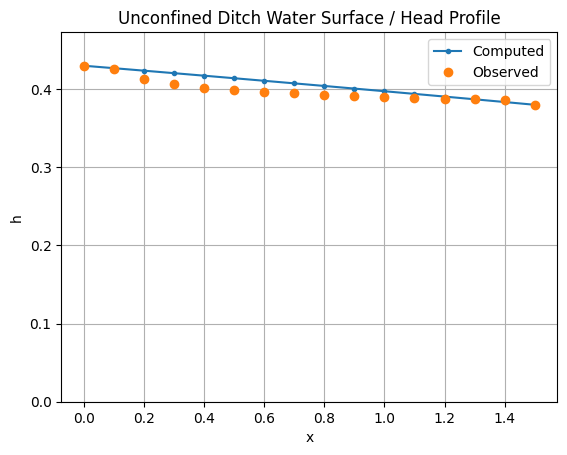

In [1]:
"""
Direct Python conversion of the Excel worksheet: UN_DITCH.xlsx
Sheet: UN_DITCH

This script reproduces the worksheet calculations in a transparent form.
It keeps the same computational logic and cell relationships as the spreadsheet.

Original workbook logic notes:
- Flow equation is marked "Flows valid when N = 0"
- Recharge / source term array w is included for future use
- The profile is computed at nx+1 stations from x = 0 to x = L
"""

from math import sqrt


def compute_unconfined_ditch(
    h1=0.43,          # Excel B3
    h2=0.38,          # Excel B4
    L=1.50,           # Excel B5
    nx=15,            # Excel B6
    width=100.0,      # Excel B7
    N=0.0,            # Excel B8 (not directly used in formulas on the sheet)
    K_cm_per_sec=0.0017,  # Excel B9
    w_values=None,    # Excel B17:Q17
    h_obs = [0.430,	0.426,	0.413,	0.407,	0.402,	0.399,	0.397,	0.395,	0.393,	0.391,	0.390,	0.389,	0.388,	0.387,	0.386,	0.380
]
):
    """
    Reproduce the spreadsheet calculations and return a dictionary of results.
    """

    # --- Unit conversions from row 9 ---
    K_m_per_sec = K_cm_per_sec / 100.0            # Excel D9 = B9/100
    K_ft_per_sec = (K_cm_per_sec / 2.54) * (1/12) # Excel F9 = (B9/2.54)*(1/12)
    K_ft_per_day = K_ft_per_sec * 60 * 60 * 24    # Excel H9 = F9*60*60*24

    # There are nx intervals and nx+1 stations
    nstations = int(nx) + 1

    # Default source/sink values, matching row 17
    if w_values is None:
        w_values = [0.0] * nstations
    else:
        if len(w_values) != nstations:
            raise ValueError(f"w_values must have length nx+1 = {nstations}")

    # --- Flow valid when N = 0 (Excel B13) ---
    # Q(CMS)=((($F$9/(2*$B$5))*($B$3^2-$B$4^2)-B$17*(0.5*$B$5-B17))*$B$7
    Q_cms = (((K_m_per_sec / (2 * L)) * (h1**2 - h2**2) - w_values[0] * (0.5 * L - w_values[0])) * width)

    # --- Station coordinates (row 19) ---
    dx = L / nx
    x = [i * dx for i in range(nstations)]

    # --- h^2 row (row 22) ---
    h_squared = [0.0] * nstations
    h_squared[0] = h1 ** 2             # Excel B22 = B20^2
    h_squared[-1] = h2 ** 2            # Excel Q22 = Q20^2

    # For interior stations, Excel uses:
    # = $B$22 - ($B$22-$Q$22)*x/L + w*(L-x)*x/$H$9
    for i in range(1, nstations - 1):
        xi = x[i]
        wi = w_values[i]
        h_squared[i] = (
            h_squared[0]
            - (h_squared[0] - h_squared[-1]) * xi / L
            + wi * (L - xi) * xi / K_ft_per_day
        )

    # --- h row (row 20) ---
    h = [0.0] * nstations
    h[0] = h1
    h[-1] = h2
    for i in range(1, nstations - 1):
        h[i] = sqrt(h_squared[i])

    return {
        "inputs": {
            "h1_m": h1,
            "h2_m": h2,
            "L_m": L,
            "nx": nx,
            "width": width,
            "N": N,
            "K_cm_per_sec": K_cm_per_sec,
        },
        "conversions": {
            "K_m_per_sec": K_m_per_sec,
            "K_ft_per_sec": K_ft_per_sec,
            "K_ft_per_day": K_ft_per_day,
            "dx": dx,
        },
        "Q_cms": Q_cms,
        "w": w_values,
        "x": x,
        "h": h,
        "h_squared": h_squared,
        "h_obs": h_obs,
    }


def print_results(results):
    print("Unconfined Ditch Results")
    print("-" * 60)
    print(f"Q (cms)      = {results['Q_cms']:.12g}")
    print(f"K (m/s)      = {results['conversions']['K_m_per_sec']:.12g}")
    print(f"K (ft/s)     = {results['conversions']['K_ft_per_sec']:.12g}")
    print(f"K (ft/day)   = {results['conversions']['K_ft_per_day']:.12g}")
    print(f"dx           = {results['conversions']['dx']:.12g}")
    print()

    print(f"{'i':>3} {'x':>12} {'w':>12} {'h':>12} {'h^2':>12} {'h_obs':>12}")
    for i, (xi, wi, hi, h2i, hobsi) in enumerate(zip(results["x"], results["w"], results["h"], results["h_squared"],results["h_obs"])):
        print(f"{i:>3d} {xi:>12.6f} {wi:>12.6f} {hi:>12.6f} {h2i:>12.6f} {hobsi:>12.6f}")


if __name__ == "__main__":
    results = compute_unconfined_ditch()
    print_results(results)

    # Optional plotting example:
    #

    import matplotlib.pyplot as plt

    plt.figure()

# Model results
    plt.plot(results["x"], results["h"], marker=".", label="Computed")

# Observations
    plt.plot(results["x"], results["h_obs"], marker="o", linestyle="none", label="Observed")

    plt.xlabel("x")
    plt.ylabel("h")
    plt.title("Unconfined Ditch Water Surface / Head Profile")

    plt.ylim(0, max(results["h"]) * 1.1)

    plt.grid(True)
    plt.legend()   # <-- important for distinguishing lines

    plt.show()
